# **Lennard-Jones gas**

In this code we simulate a set of N particles subjected to Lennard-Jones interactions and confined in a 2D rectangular box. We do this by using the 12-6 Lennard-Jones potential. Then, we solve numerically the Newton's law of motion using Runge-kutta 4. Besides, we use a rustic method of adaptive step by reducing the time step when two particles are *close enough*. The condition for *close enough* is that any of the forces between the particles be greater than or equal to `F0`, which is the Lennard-Jones force between two particles at some distant `R0`. This distance must be choose by the user.

**Credits**
* Juan Andrés Guarín Rojas
* [GitHub](https://github.com/AndresGuarin)

# **Import libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LJGas.solver.particles as partic
import LJGas.solver.animation as ani
import LJGas.analysis.pressure as press

#import LJGas.solver.animation2 as ani
#import LJGas.solver.particles2 as partic

from LJGas.analysis.visualization import moving_mean

from datetime import datetime

# **1. Test Simulation of 30 particles**

In [88]:
def get_R(X0,Y0):
    I = np.eye(Np)
    A, B = np.meshgrid(X0,X0); dX = A-B
    A, B = np.meshgrid(Y0,Y0); dY = A-B 
    return np.sqrt(dX**2+dY**2) + I

In [89]:
def eliminate_close_particles(Np,X0,Y0,Vx0,Vy0,R0,thr=0.2,verbose=False):
    R = get_R(X0,Y0)
    Rtriag = R*np.triu(np.ones((Np,Np))) + 20*thr*R0*np.tril(np.ones((Np,Np)))
    ii = Rtriag<=thr*R0
    if verbose: print(Rtriag[ii])
    rows, cols = np.where(ii)
    eList = list(zip(rows,cols))
    jj = np.ones(Np,dtype=bool)
    for e in eList: jj[e[0]] = False
    return X0[jj], Y0[jj], Vx0[jj], Vy0[jj], Np-len(eList)

In [117]:
# Random start

# Choose parameters 
h = 0.02; N = 10000; R0 = 1.05; h0 = 0.01; box=[10,10]; R1=3

# Set intial conditions
Np = 30

np.random.seed(174)
X0 = np.random.random(Np)*box[0]*0.9 - box[0]*0.9/2
Y0 = np.random.random(Np)*box[1]*0.9 - box[1]*0.9/2
Theta0 = np.random.random(Np)*2*np.pi - np.pi
Vx0 = 1.2*np.cos(Theta0) + np.random.random(Np)*0.1 - 0.1
Vy0 = 1.2*np.sin(Theta0) + np.random.random(Np)*0.1 - 0.1
#X0 = Xf; Y0 = Yf; Vx0 = Vxf; Vy0 = Vyf

X0, Y0, Vx0, Vy0, Np = eliminate_close_particles(Np,X0,Y0,Vx0,Vy0,R0,0.5*R0,True)

[0.15102543 0.45443732 0.34655565 0.174366  ]


In [ ]:
# Unlikely initial start

# Choose parameters 
h = 0.01; N = 10000; R0 = 1.05; h0 = 0.01; box=[20,20]; alpha=20; R1=3

# Set intial conditions
Np = 25

np.random.seed(17449)
X0 = np.random.random(Np)*box[0]*0.9 - box[0]*0.9/2
Y0 = np.random.random(Np)*box[1]*0.9 - box[1]*0.9/2
Theta0 = np.random.random(Np)*2*np.pi - np.pi
Vx0 = 1.2*np.cos(Theta0) + np.random.random(Np)*0.1
Vy0 = 1.2*np.sin(Theta0) + np.random.random(Np)*0.1
#X0 = Xf; Y0 = Yf; Vx0 = Vxf; Vy0 = Vyf

In [118]:
sim = partic.LJGas(h,N,Np,R0,h0,box,R1,verbose=False)
s = sim.simulate([X0,Y0,Vx0,Vy0])
self1 = sim.get_self()
Lh = self1.Lh
time = np.zeros(N+1)
for i in range(N): time[i+1] = time[i]+Lh[i]

In [149]:
np.mean(Vx0), np.mean(Vy0)

(0.05346962322715225, -0.07304435901634822)

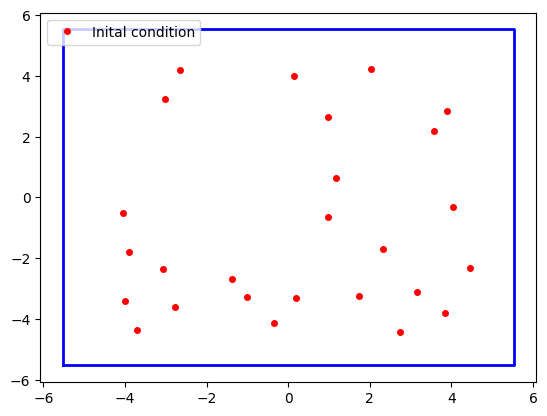

In [120]:
%matplotlib inline

Xf = s[0][-1,:]; Yf = s[1][-1,:]; Vxf = s[2][-1,:]; Vyf = s[3][-1,:]

b0 = box[0]/2 + R0/2; b1 = box[1]/2 + R0/2
plt.plot([-b0,b0,b0,-b0,-b0],[-b1,-b1,b1,b1,-b1],'-b',lw=2)
plt.plot(X0,Y0,'or',ms=4,label='Inital condition')
#plt.plot(X0,Y0,'or',ms=4,label='Final condition')
plt.legend(loc='upper left')
plt.show()

# **2. Animation**

In [121]:
date = 'module_test'
#date = datetime.now().strftime("%m-%d_%H-%M-%S")

In [122]:
%matplotlib auto
%matplotlib auto

ani.animate_path(self1,s,dj=5,kind=0,save=False,name=date+'test.mp4',verbose=True,plot_params=['-b','or',0.5,5,0.3],amp=3,interval=100)
#plt.show()

Using matplotlib backend: QtAgg
Using matplotlib backend: QtAgg


# **3. Analysis**

In [123]:
%matplotlib inline

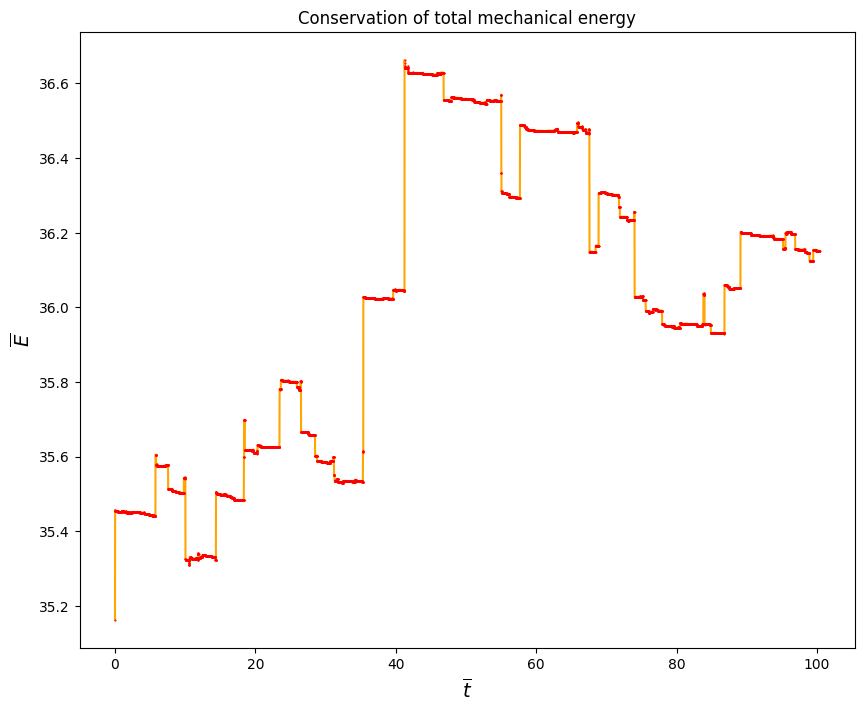

In [124]:
Em = sim.get_Energy(s)[2]

plt.figure(figsize=(10,8))
plt.title('Conservation of total mechanical energy')
plt.ylabel(r'$\overline{E}$',fontsize=14)
plt.xlabel(r'$\overline{t}$',fontsize=14)
plt.plot(time,Em,'-',color='orange') ;plt.plot(time,Em,'o',color='red', ms=0.5)
plt.savefig('images/NParticlesGas/'+date+' mechanical_energy.png',dpi=350)
plt.show()

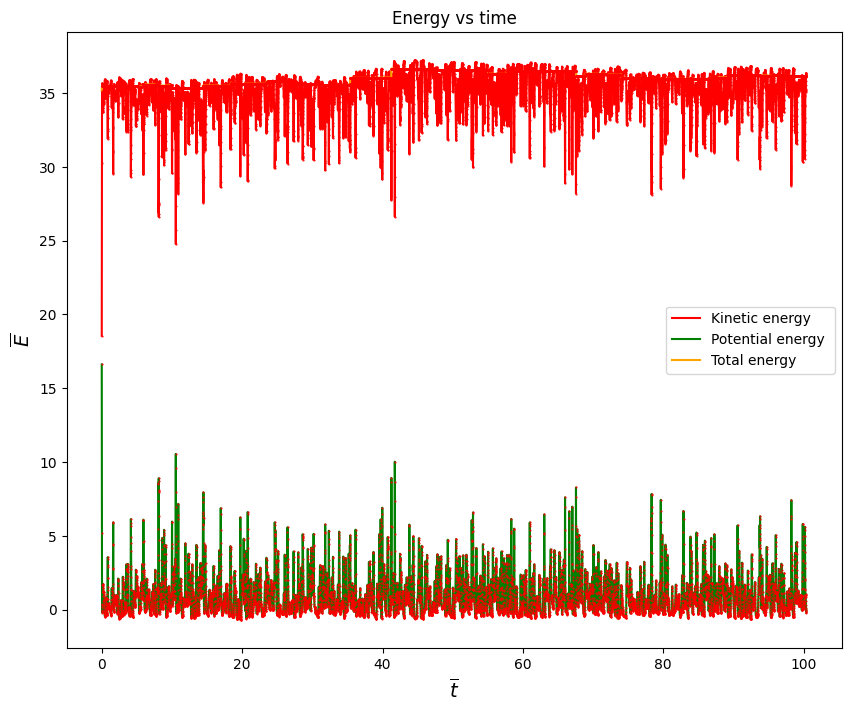

In [125]:
Ek, V, Em  = sim.get_Energy(s)

plt.figure(figsize=(10,8))
plt.title('Energy vs time')
plt.ylabel(r'$\overline{E}$',fontsize=14)
plt.xlabel(r'$\overline{t}$',fontsize=14)
plt.plot(time, Ek,'-',color='red',label = 'Kinetic energy') ;plt.plot(time, Ek,'o',color='red', ms=0.5)
plt.plot(time, V,'-',color='green',label = 'Potential energy ') ;plt.plot(time, V,'o',color='red', ms=0.5)
plt.plot(time, Em,'-',color='orange',label = 'Total energy') ;plt.plot(time, Em,'o',color='red', ms=0.5)
plt.legend()
plt.savefig('images/NParticlesGas/'+date+' energy.png',dpi=350)
plt.show()

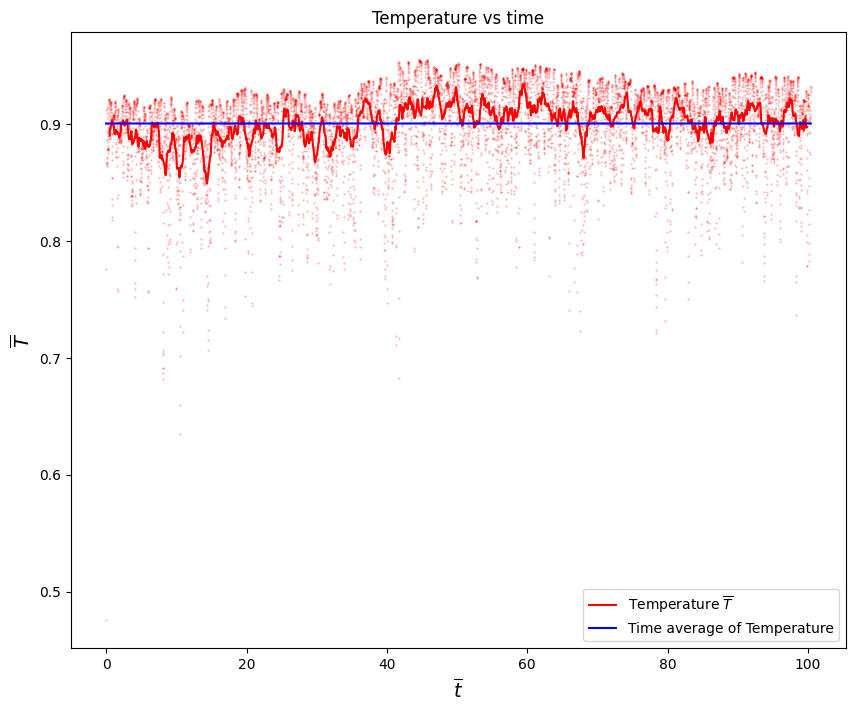

In [126]:
Ek, V, Em  = sim.get_Energy(s)
T = Ek*2/(3*self1.Np)
Tmean = np.mean(T)*np.ones(len(Ek))
#Em_mean = np.mean(Em*2/(3*self1.Np))*np.ones(len(Em))

time1, T1 = moving_mean(time,T,w=100)
plt.figure(figsize=(10,8))
plt.title('Temperature vs time')
plt.ylabel(r'$\overline{T}$',fontsize=14)
plt.xlabel(r'$\overline{t}$',fontsize=14)
plt.plot(time1, T1,'-',color='red',label = r'Temperature $\overline{T}$') ;plt.plot(time, T,'o',color='red',alpha=0.3, ms=0.5)
plt.plot(time, Tmean,'-',color='blue',label = r'Time average of Temperature')
#plt.plot(time, Em_mean,'-',color='cyan',label = r'Time average of $\frac{2}{3N_p}\overline{E}$')
plt.legend()
plt.savefig('images/NParticlesGas/'+date+' temperature.png',dpi=350)
plt.show()

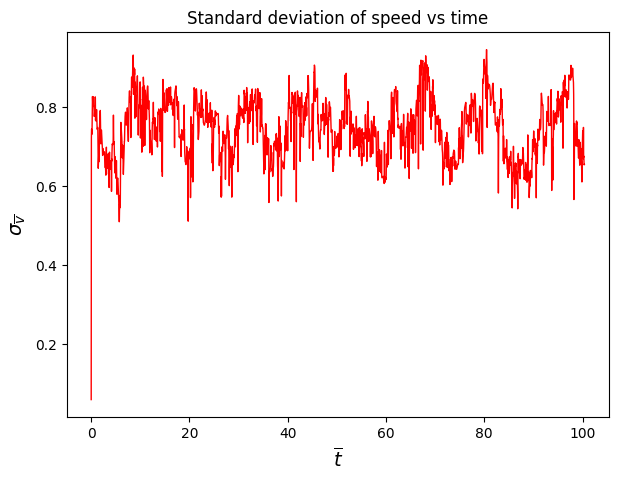

In [127]:
MV = np.sqrt(s[2]**2+s[3]**2)
MV_std = np.std(MV,axis=1)

plt.figure(figsize=(7,5))
plt.title('Standard deviation of speed vs time')
plt.ylabel(r'$\sigma_\overline{v}$',fontsize=14)
plt.xlabel(r'$\overline{t}$',fontsize=14)
plt.plot(time, MV_std,'-',color='red',lw=1)
plt.show()

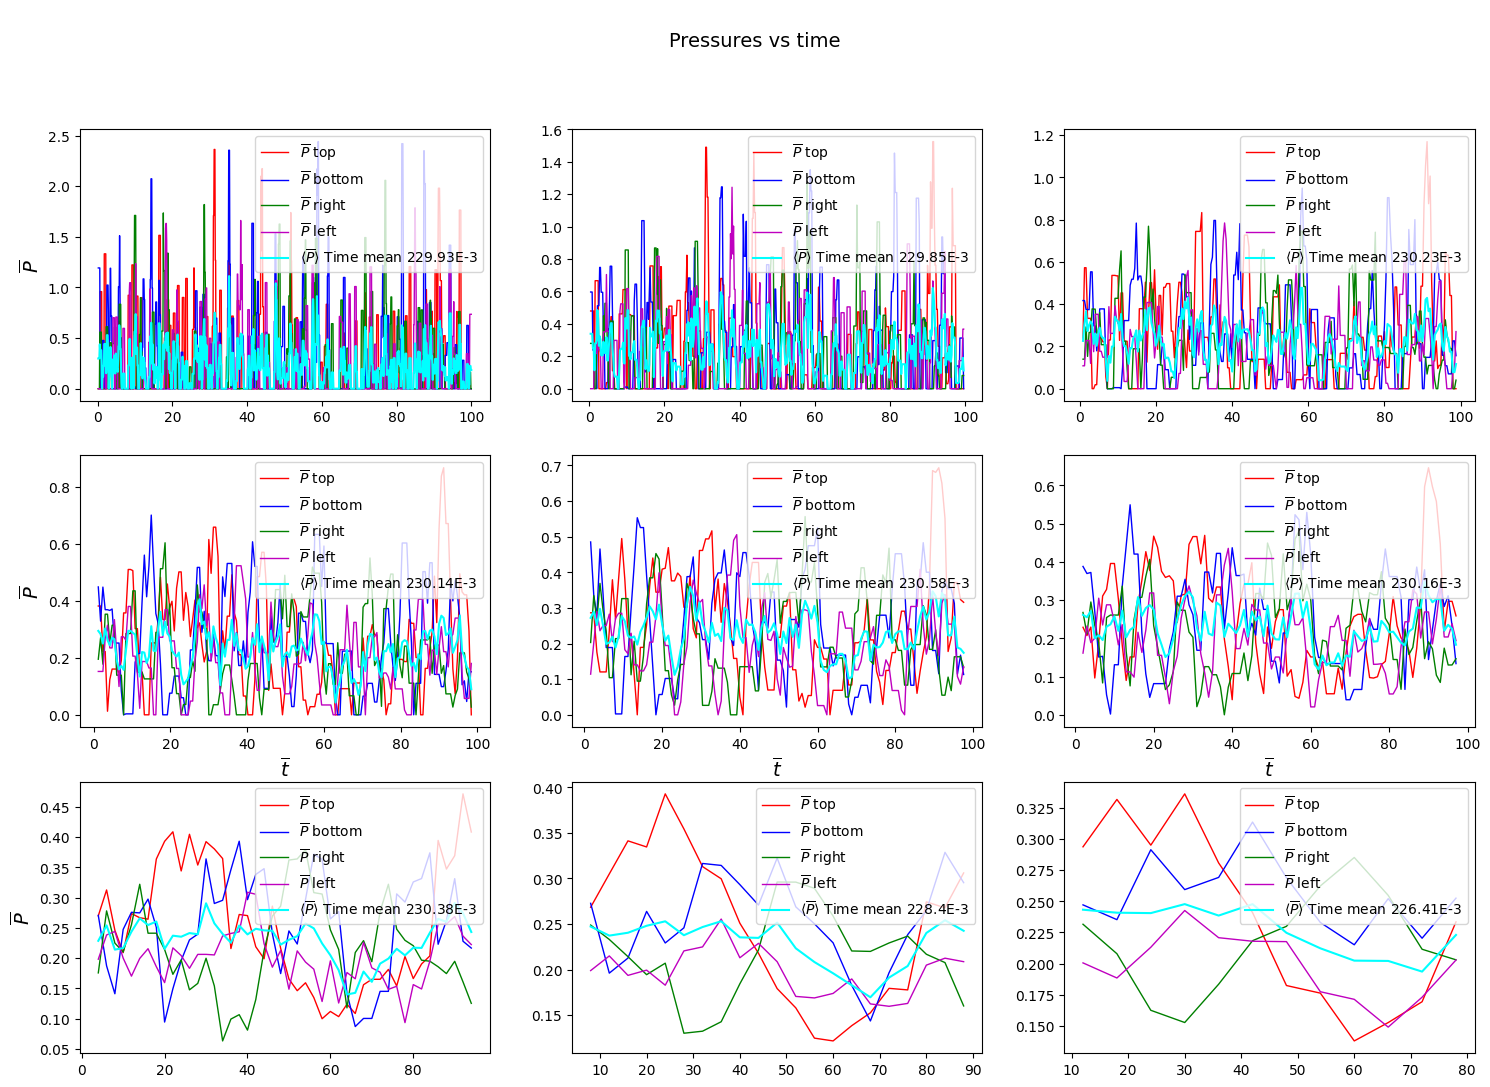

In [128]:
#Ldt = [5*h, 10*h, 20*h, 30*h, 40*h, 50*h, 60*h, 80*h, 100*h]
Ldt = [5*h, 10*h, 20*h, 30*h, 40*h, 50*h, 100*h, 200*h, 300*h]
press.plot_pressure_charts(s,time,box,Ldt,date=date,save=True)
plt.show()

In [156]:
Kmean = 3/2*np.mean(T)
P_predicted = Np*Kmean/(box[0]*box[1])

print(f'P predicted: {np.round(np.mean(P_predicted)*10**3,3)}E-3')
P_mean = float(input())
print('%Error:',np.round(100*(P_predicted-P_mean)/P_predicted,1))

P predicted: 351.168E-3
%Error: 100.0


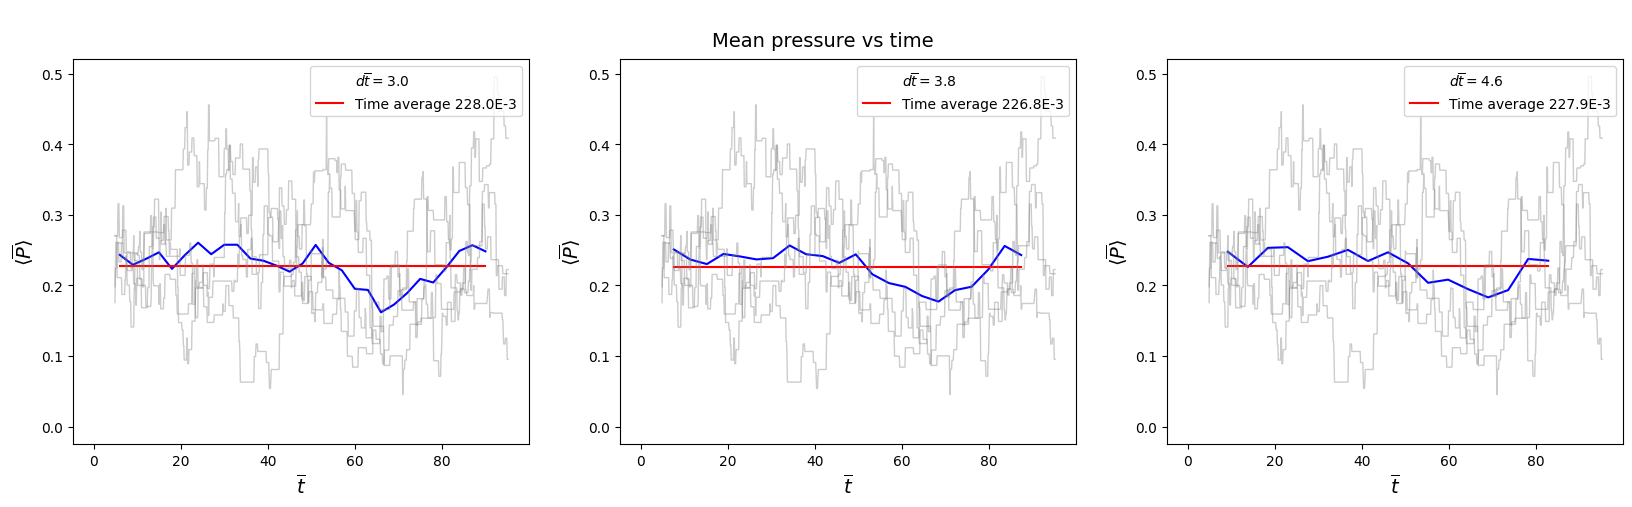

In [130]:
#Ldt = [60*h, 80*h, 100*h]
Ldt = [150*h, 190*h, 230*h]
press.plot_pressure_line(s,time,box,Ldt,h,w2=100,date=date,save=True)
plt.show()

In [132]:
print(f'Delta t: {2*box[0]/np.max(np.abs(Vx0))}')
print(f'Delta t: {2*box[0]/np.max(np.abs(Vx0))}')

Delta t: 16.522447560609688
Delta t: 16.522447560609688


In [153]:
i = 100; Vxf = s[2][i]; Vyf = s[3][i]
np.mean(Vyf**2), np.mean(Vxf**2), 1/2*np.mean(Vxf**2+Vyf**2)

(1.5968331530517152, 1.1128853970501853, 1.3548592750509505)